# 回帰分析の課題

このノートブックでは、課題の内容に合わせて2つの回帰分析を行います。

1. `feature_engineering_dataset.csv` に対して、二乗・三乗の特徴量を作り、Lasso 回帰を行う
2. `Material_Lifespan_Dataset_encoded_sklearn.csv` に対して、SVR で `PredictedHours` を予測する

コードの近くに「何をしているのか」が分かるようにコメントを付けています。


## 1. ライブラリの準備

必要なライブラリを読み込みます。もしライブラリが入っていない場合は、自動でインストールします。


In [32]:
# importlib は、ライブラリがインストール済みか確認するために使います。
import importlib

# subprocess と sys は、足りないライブラリを pip で入れるために使います。
import subprocess
import sys


def install_if_needed(package_name, import_name=None):
    """指定したライブラリが未インストールの場合だけ追加します。"""
    module_name = import_name or package_name
    try:
        # ライブラリを読み込めるか試します。
        importlib.import_module(module_name)
    except ModuleNotFoundError:
        # 読み込めなかった場合だけ、現在の Python 環境にインストールします。
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


install_if_needed("pandas")
install_if_needed("scikit-learn", "sklearn")
install_if_needed("matplotlib")


In [33]:
# Path は、CSVファイルの場所を扱いやすくするために使います。
from pathlib import Path

# グラフ描画と表データ処理に使うライブラリです。
import matplotlib.pyplot as plt
import pandas as pd

# LassoCV は、Lasso回帰の強さをクロスバリデーションで決めるモデルです。
# LinearRegression と Ridge は、比較用の基本的な回帰モデルです。
from sklearn.linear_model import LassoCV, LinearRegression, Ridge

# 評価指標を計算する関数です。
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# データ分割とクロスバリデーションに使います。
from sklearn.model_selection import KFold, cross_validate, train_test_split

# Pipeline は「前処理 → モデル学習」をまとめるために使います。
from sklearn.pipeline import make_pipeline

# PolynomialFeatures は二乗・三乗特徴量を作ります。
# StandardScaler は特徴量の尺度をそろえます。
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# SVR は、サポートベクター回帰のモデルです。
from sklearn.svm import SVR

# CSVファイルがあるフォルダを指定します。
DATA_DIR = Path.cwd()
if not (DATA_DIR / "feature_engineering_dataset.csv").exists():
    DATA_DIR = Path("/Users/t-shuichi/Developer/seminar4/prac")

# seed を固定すると、データ分割などのランダム処理を再現できます。
RANDOM_STATE = 42

# 5分割クロスバリデーションの設定です。
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 2. 用語整理

- **クロスバリデーション**：データを複数に分け、学習用と検証用を入れ替えながら性能を確認する方法です。1回の分割だけに依存しにくくなります。
- **データリーク**：本来は学習時に使えない情報が混ざってしまうことです。たとえば、テストデータの情報を使って標準化してから評価すると、実力より良く見えてしまいます。
- **再現性（seed）**：同じコードを実行したときに同じ結果を得られることです。`random_state=42` のように seed を固定します。
- **特徴量エンジニアリング**：元の説明変数から、予測に役立つ新しい特徴量を作ることです。今回は `x1^2` や `x1^3` のような二乗・三乗特徴量を作ります。
- **SVR（サポートベクター回帰）**：サポートベクターマシンを回帰に使う方法です。ある程度の誤差を許容しながら、重要なデータ点を使って予測線・予測曲面を作ります。RBFカーネルを使うと、非線形な関係も扱えます。


## 3. `feature_engineering_dataset.csv` の読み込み

まずは、特徴量エンジニアリングと Lasso 回帰を行うデータを読み込みます。目的変数は `y` です。


In [34]:
# CSVファイルを DataFrame として読み込みます。
feature_df = pd.read_csv(DATA_DIR / "feature_engineering_dataset.csv")

# 先頭5行を表示して、どのような列があるか確認します。
feature_df.head()


,x1,x2,x3,x4,y
0,-1.254599,-3.148671,-2.382943,1.727030,4.474510
1,4.507143,0.419009,-2.530212,2.966814,16.006309
2,2.319939,3.729458,4.062546,-2.495321,-1.629434
3,0.986585,2.322249,-2.504538,1.248741,1.787929
4,-3.439814,3.065611,-2.280503,0.717460,5.071840


In [35]:
# 各列のデータ型や欠損値の有無を確認します。
feature_df.info()

# 平均、標準偏差、最小値、最大値などの基本統計量を確認します。
feature_df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1000 non-null   float64
 1   x2      1000 non-null   float64
 2   x3      1000 non-null   float64
 3   x4      1000 non-null   float64
 4   y       1000 non-null   float64
dtypes: float64(5)
memory usage: 39.2 KB


,x1,x2,x3,x4,y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.097434,0.070173,0.024057,-0.096250,3.931043
std,2.921374,2.921899,2.906742,2.864893,10.173608
min,-4.953680,-4.967817,-4.999884,-4.993466,-23.903197
25%,-2.640267,-2.589257,-2.386490,-2.580992,-1.257002
50%,-0.031926,0.187339,0.006139,-0.157207,3.407059
75%,2.443196,2.604651,2.591035,2.375408,9.433207
max,4.997177,4.994137,4.978209,4.995577,38.728776


## 4. 説明変数と目的変数に分ける

`x1` から `x4` を説明変数、`y` を目的変数として使います。モデルの性能確認のため、学習データとテストデータに分けます。


In [36]:
# y を予測したいので、y 以外の列を説明変数 X にします。
X = feature_df.drop(columns="y")

# 予測したい列 y を目的変数にします。
y = feature_df["y"]

# 学習用80%、テスト用20%に分けます。
# random_state を固定することで、毎回同じ分割になります。
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("学習データ:", X_train.shape)
print("テストデータ:", X_test.shape)


学習データ: (800, 4)
テストデータ: (200, 4)


## 5. 特徴量エンジニアリング + Lasso 回帰

`PolynomialFeatures(degree=3)` で二乗・三乗・交互作用の特徴量を追加します。特徴量を増やすと不要な項も混ざるため、不要な係数を 0 に近づける Lasso 回帰を使います。

`LassoCV` は、正則化の強さ `alpha` をクロスバリデーションで選びます。`Pipeline` に前処理とモデルをまとめることで、標準化の処理によるデータリークを防ぎます。


In [37]:
# 比較用に、普通の線形回帰、Ridge回帰、特徴量追加ありのLasso回帰を用意します。
feature_models = {
    "Linear Regression": make_pipeline(
        StandardScaler(),
        LinearRegression(),
    ),
    "Ridge Regression": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0),
    ),
    "Lasso + Polynomial(degree=3)": make_pipeline(
        # 元の x1〜x4 から、二乗・三乗・交互作用の特徴量を作ります。
        PolynomialFeatures(degree=3, include_bias=False),
        # Lassoはスケールの影響を受けやすいので標準化します。
        StandardScaler(),
        # alpha をクロスバリデーションで選ぶ Lasso です。
        LassoCV(cv=cv, max_iter=20000, random_state=RANDOM_STATE),
    ),
}

results = []

for model_name, model in feature_models.items():
    # 学習データでモデルを学習します。
    model.fit(X_train, y_train)

    # テストデータで予測します。
    y_pred = model.predict(X_test)

    # 予測結果を評価します。
    results.append(
        {
            "model": model_name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
            "R2": r2_score(y_test, y_pred),
        }
    )

# R2 が高い順に並べて、どのモデルがよいか比較します。
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df


,model,MAE,RMSE,R2
2,Lasso + Polynomial(degree=3),1.642643,2.065452,0.959813
0,Linear Regression,4.931001,6.018583,0.658777
1,Ridge Regression,4.930558,6.018871,0.658744


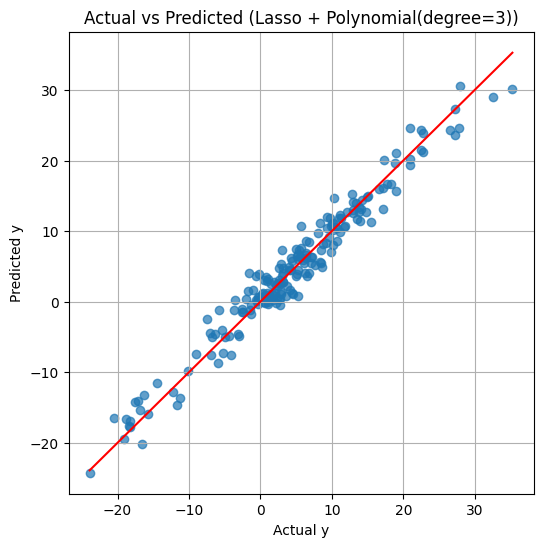

In [38]:
# 一番 R2 が高かったモデルを取り出します。
best_model_name = results_df.iloc[0]["model"]
best_model = feature_models[best_model_name]

# テストデータに対する予測値を作ります。
best_pred = best_model.predict(X_test)

# 実測値と予測値を散布図で比較します。
# 点が赤い斜め線に近いほど、予測がよくできています。
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.grid(True)
plt.show()


### Lasso が選んだ特徴量を確認する

Lasso は不要な特徴量の係数を 0 にします。どの特徴量が残ったかを確認すると、どの特徴量が予測に使われたかを理解できます。


In [39]:
# 学習済みの Lasso パイプラインを取り出します。
lasso_pipeline = feature_models["Lasso + Polynomial(degree=3)"]

# パイプライン内の PolynomialFeatures と LassoCV を取り出します。
poly = lasso_pipeline.named_steps["polynomialfeatures"]
lasso = lasso_pipeline.named_steps["lassocv"]

print(f"クロスバリデーションで選ばれた alpha: {lasso.alpha_:.4f}")

# 作られた特徴量名と、それぞれの係数を表にします。
coef_df = pd.DataFrame(
    {
        "feature": poly.get_feature_names_out(X.columns),
        "coefficient": lasso.coef_,
    }
)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# 係数が0でない特徴量だけを取り出します。
selected = coef_df[coef_df["coefficient"] != 0]
print(f"残った特徴量: {len(selected)} / {len(coef_df)}")

# 係数の絶対値が大きい順に並べます。
selected.sort_values("abs_coefficient", ascending=False)


クロスバリデーションで選ばれた alpha: 0.0745
残った特徴量: 7 / 34


,feature,coefficient,abs_coefficient
33,x4^3,9.142956,9.142956
4,x1^2,3.682781,3.682781
20,x1 x2 x4,0.110058,0.110058
21,x1 x3^2,-0.085404,0.085404
28,x2 x3 x4,-0.073029,0.073029
19,x1 x2 x3,-0.051616,0.051616
18,x1 x2^2,-0.007587,0.007587


## 6. 材料寿命データで SVR を行う

次に、材料寿命データの `PredictedHours` を予測します。課題文では `Material_Lifespan_Dataset.csv` とありますが、このフォルダには数値化済みの `Material_Lifespan_Dataset_encoded_sklearn.csv` があるため、それを使います。

SVR は特徴量のスケールに敏感なので、`StandardScaler` で標準化してから学習します。ここでも `Pipeline` を使い、標準化を学習データ内だけで行うことでデータリークを防ぎます。


In [40]:
# 材料寿命データを読み込みます。
material_df = pd.read_csv(DATA_DIR / "Material_Lifespan_Dataset_encoded_sklearn.csv")

# 先頭5行を見て、列の構成を確認します。
material_df.head()


,PredictedHours,CoolRate,QuenchDuration,ForgeDuration,HeatProcessTime,NickelComposition,IronComposition,CobaltComposition,ChromiumComposition,MinorDefects,...,ComponentType_Nozzle,ComponentType_Valve,StructureType_colGrain,StructureType_equiGrain,StructureType_singleGrain,InitialPosition_Bottom,InitialPosition_Top,FormationMethod_Continuous,FormationMethod_Die,FormationMethod_Investment
0,1461.797,12.836,3.803,6.515,47.005,65.450,16.618,16.510,0.938,10,...,1,0,0,1,0,1,0,0,1,0
1,1825.977,19.032,2.593,3.521,45.246,54.162,34.916,6.063,4.292,19,...,0,0,0,0,1,1,0,0,0,1
2,707.101,28.418,0.772,1.327,9.639,52.565,36.486,8.927,3.355,35,...,0,0,0,1,0,1,0,0,0,1
3,1086.370,9.084,1.990,2.201,20.009,56.665,23.436,17.040,2.827,0,...,1,0,1,0,0,0,1,1,0,0
4,1813.529,16.196,4.092,3.881,15.904,60.502,26.995,11.382,1.564,10,...,0,0,1,0,0,0,1,0,1,0


In [41]:
# 予測したい目的変数を指定します。
target_column = "PredictedHours"

# PredictedHours 以外を説明変数にします。
X_material = material_df.drop(columns=target_column)

# PredictedHours を目的変数にします。
y_material = material_df[target_column]

# 学習用80%、テスト用20%に分けます。
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_material,
    y_material,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

# SVRモデルを作ります。
# RBFカーネルを使うことで、非線形な関係も扱えます。
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", C=1000, epsilon=20, gamma="scale"),
)

# 学習データでSVRを学習します。
svr_model.fit(X_train_m, y_train_m)

# テストデータでPredictedHoursを予測します。
svr_pred = svr_model.predict(X_test_m)

# 予測性能を評価します。
svr_scores = pd.DataFrame(
    [
        {
            "model": "SVR (RBF kernel)",
            "MAE": mean_absolute_error(y_test_m, svr_pred),
            "RMSE": mean_squared_error(y_test_m, svr_pred) ** 0.5,
            "R2": r2_score(y_test_m, svr_pred),
        }
    ]
)

svr_scores


,model,MAE,RMSE,R2
0,SVR (RBF kernel),147.626814,186.484468,0.664074


## 7. クロスバリデーションで SVR を評価する

1回の train/test 分割だけでなく、5分割クロスバリデーションでも SVR の性能を確認します。`cross_validate` に `svr_model` という Pipeline を渡しているため、各分割の中で標準化と学習が行われます。


In [42]:
# 5分割クロスバリデーションで、SVRの性能を確認します。
cv_scores = cross_validate(
    svr_model,
    X_material,
    y_material,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2",
    },
)

# scikit-learn では MAE と RMSE が負の値で返るため、見やすいように -1 をかけます。
cv_summary = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "mean": [
            -cv_scores["test_MAE"].mean(),
            -cv_scores["test_RMSE"].mean(),
            cv_scores["test_R2"].mean(),
        ],
        "std": [
            cv_scores["test_MAE"].std(),
            cv_scores["test_RMSE"].std(),
            cv_scores["test_R2"].std(),
        ],
    }
)

cv_summary


,metric,mean,std
0,MAE,152.772162,8.223921
1,RMSE,192.606889,11.162411
2,R2,0.678155,0.035257


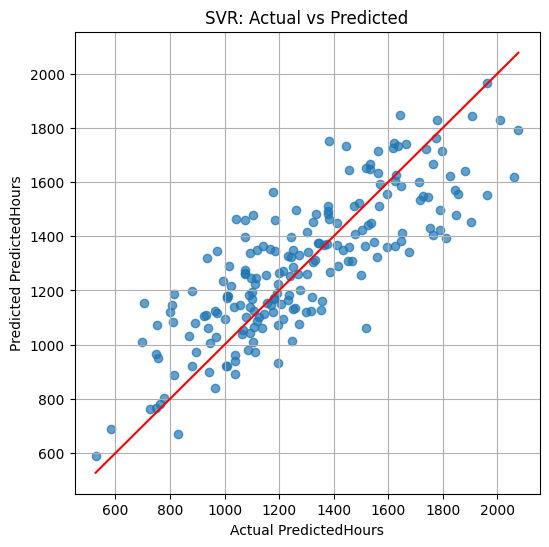

In [43]:
# 実測値とSVRの予測値を散布図で比較します。
plt.figure(figsize=(6, 6))
plt.scatter(y_test_m, svr_pred, alpha=0.7)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], color="red")
plt.xlabel("Actual PredictedHours")
plt.ylabel("Predicted PredictedHours")
plt.title("SVR: Actual vs Predicted")
plt.grid(True)
plt.show()


## 8. 新しいデータを予測する例

テストデータの先頭5件を使って、SVR がどのような値を予測するか確認します。


In [44]:
# テストデータの先頭5件を例として取り出します。
sample_X = X_test_m.head(5)

# 学習済みSVRで予測します。
sample_prediction = svr_model.predict(sample_X)

# 説明変数、実測値、予測値を1つの表にまとめます。
prediction_df = sample_X.copy()
prediction_df["actual_PredictedHours"] = y_test_m.head(5).values
prediction_df["predicted_PredictedHours"] = sample_prediction

prediction_df


,CoolRate,QuenchDuration,ForgeDuration,HeatProcessTime,NickelComposition,IronComposition,CobaltComposition,ChromiumComposition,MinorDefects,MajorDefects,...,StructureType_colGrain,StructureType_equiGrain,StructureType_singleGrain,InitialPosition_Bottom,InitialPosition_Top,FormationMethod_Continuous,FormationMethod_Die,FormationMethod_Investment,actual_PredictedHours,predicted_PredictedHours
521,21.365,1.340,2.477,36.382,69.264,8.491,17.784,4.566,39,0,...,0,0,1,0,1,1,0,0,1567.417,1510.979184
737,16.792,1.092,1.313,5.149,69.296,14.379,10.397,4.778,26,0,...,0,0,1,1,0,1,0,0,1826.765,1623.349296
740,27.354,2.685,2.551,52.243,63.894,29.684,6.196,0.843,30,3,...,1,0,0,0,1,0,0,1,973.564,1116.068834
660,15.060,1.788,9.544,16.377,59.044,27.710,9.992,2.384,12,0,...,1,0,0,1,0,0,1,0,1380.756,1481.321504
411,15.752,3.154,7.842,53.596,51.767,35.907,7.254,4.454,26,0,...,1,0,0,0,1,0,1,0,1342.511,1375.766148


## 9. 使用した関数・コードのまとめ

| 関数・コード | 意味 |
|---|---|
| `pd.read_csv(...)` | CSVファイルを読み込み、表形式の `DataFrame` にする |
| `.head()` | データの先頭5行を表示する |
| `.info()` | 列名、データ型、欠損値の有無を確認する |
| `.describe()` | 平均、標準偏差、最小値、最大値などを確認する |
| `drop(columns="y")` | 指定した列を取り除く。ここでは目的変数以外を説明変数にするために使う |
| `train_test_split(...)` | データを学習用とテスト用に分ける |
| `random_state=42` | ランダム処理の結果を固定して、再現性を持たせる |
| `KFold(n_splits=5, shuffle=True, random_state=42)` | データを5分割してクロスバリデーションを行う設定 |
| `make_pipeline(...)` | 前処理とモデルを1つにまとめる。データリーク防止にも役立つ |
| `PolynomialFeatures(degree=3)` | 元の特徴量から二乗・三乗・交互作用の特徴量を作る |
| `StandardScaler()` | 平均0、標準偏差1になるように特徴量を標準化する |
| `LassoCV(...)` | Lasso回帰を行い、`alpha` をクロスバリデーションで選ぶ |
| `SVR(kernel="rbf", C=1000, epsilon=20)` | RBFカーネルを使ったサポートベクター回帰モデルを作る |
| `.fit(X_train, y_train)` | 学習データを使ってモデルを学習する |
| `.predict(X_test)` | 学習済みモデルで予測値を出す |
| `mean_absolute_error(...)` | MAEを計算する。予測誤差の絶対値の平均 |
| `mean_squared_error(...) ** 0.5` | RMSEを計算する。大きな誤差を重く見る指標 |
| `r2_score(...)` | R2を計算する。1に近いほどよく予測できている |
| `cross_validate(...)` | クロスバリデーションで複数の評価指標を計算する |
| `plt.scatter(...)` | 散布図を描く |
| `plt.plot(...)` | 線を描く。ここでは実測値=予測値の基準線を描く |
| `coef_` | Lassoが学習した各特徴量の係数 |
| `get_feature_names_out(...)` | `PolynomialFeatures` で作られた特徴量名を取得する |

### このノートブックで行ったことの流れ

1. CSVファイルを読み込む
2. 説明変数 `X` と目的変数 `y` に分ける
3. 学習データとテストデータに分ける
4. `feature_engineering_dataset.csv` では二乗・三乗特徴量を作って Lasso 回帰を行う
5. 材料寿命データでは SVR で `PredictedHours` を予測する
6. MAE、RMSE、R2で性能を評価する
7. クロスバリデーションで、1回の分割だけに依存しない性能を確認する
8. 散布図で実測値と予測値の関係を見る
